In [ ]:
from extraccion import minioFunctions as mf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import utm

# Limpieza de datos

* [Análisis Vegetación + Incendios](#ANALISIS-VEGETACION-+-INCENDIOS)
    * [Interpretación de los nulos en vegetación](#interpretación-de-los-nulos-en-vegetación)
    * [Nulos de la vegetación en incendios en relación con las otras variables](#nulos-de-la-vegetación-en-incendios-en-relación-con-las-otras-variables)
    * [Decisiones tomadas](#decisiones-tomadas)
* [Análisis SOC (Suelo) + Incendios](#ANALISIS-SOC-+-INCENDIOS)
* [Análisis de Físicas + Incendios](#ANALISIS-DE-FISICAS-+-INCENDIOS)
* [Análisis Vegetación2 (Tipo de Vegetación) + Incendios](#vegetación2-tipo-de-vegetación--incendios)
* [Conclusión](#CONCLUSION)
* [Posterior (Limpieza y subida a MinIO)](#POSTERIOR)

### Retoques iniciales (para preparar los datos)

In [ ]:
l_i = []
l_v = []
l_s = []
l_p = []
l_V2 = []
l_f = []
for k in [2022, 2023,2024, 2025]:
    print(f"Analizando el año {k}:")
    dataf = mf.bajar_fichero(mf.crear_cliente(), path_server=f"grupo3/raw/Incendios_y_no_incendios/incendios_y_no_incendios_{k}.parquet", type="df")
    datav = mf.bajar_fichero(mf.crear_cliente(), path_server=f"grupo3/raw/Vegetacion/incendios_y_no_incendios_Vegetacion_{k}.parquet", type="df")
    datap = mf.bajar_fichero(mf.crear_cliente(), path_server=f"grupo3/raw/Pendiente/incendios_y_no_incendios_Pendiente_{k}.parquet", type="df")
    datas = mf.bajar_fichero(mf.crear_cliente(), path_server=f"grupo3/raw/Soil_organic_carbon/soil_organic_carbon_{k}.parquet", type="df")
    dataV2 = mf.bajar_fichero(mf.crear_cliente(), path_server=f"grupo3/raw/Vegetacion2/incendios_y_no_incendios_Vegetacion2_{k}.parquet", type="df")
    datad = mf.bajar_fichero(mf.crear_cliente(), path_server=f"grupo3/raw/Fisicas/fisicas_{k}_concat.parquet", type="df")

    l_i.append(dataf)
    l_v.append(datav)
    l_p.append(datap)
    l_s.append(datas)
    l_V2.append(dataV2)
    l_f.append(datad)

df_incendios = pd.concat(l_i, ignore_index=True)
df_vegetacion = pd.concat(l_v, ignore_index=True)
df_tierra = pd.concat(l_s, ignore_index=True)
df_pendiente = pd.concat(l_p, ignore_index=True)
df_vegetacion2 = pd.concat(l_V2, ignore_index=True)
df_fisicas = pd.concat(l_f, ignore_index=True)
    

Analizando el año 2022:
Dataframe importado correctamente
Dataframe importado correctamente
Dataframe importado correctamente
Dataframe importado correctamente
Dataframe importado correctamente
Dataframe importado correctamente
Analizando el año 2023:
Dataframe importado correctamente
Dataframe importado correctamente
Dataframe importado correctamente
Dataframe importado correctamente
Dataframe importado correctamente
Dataframe importado correctamente
Analizando el año 2024:
Dataframe importado correctamente
Dataframe importado correctamente
Dataframe importado correctamente
Dataframe importado correctamente
Dataframe importado correctamente
Dataframe importado correctamente
Analizando el año 2025:
Dataframe importado correctamente
Dataframe importado correctamente
Dataframe importado correctamente
Dataframe importado correctamente
Dataframe importado correctamente
Dataframe importado correctamente


In [ ]:
#Longitud de cada dataframe con cada variable
print(len(df_incendios), len(df_vegetacion), len(df_tierra), len(df_pendiente), len(df_vegetacion2), len(df_fisicas))

73472 73472 73472 73472 73470 73443


In [ ]:
dfi = df_incendios.copy()
dfv = df_vegetacion.copy()
dfs = df_tierra.copy()
dfp = df_pendiente.copy()
dfv2 = df_vegetacion2.copy()
dff = df_fisicas.copy()

In [ ]:
dfi["date_first"] = dfi["date_first"].str[:10]
dfv['date'] = dfv['date'].str[:10]
dfs['date'] = dfs['date'].str[:10]
dfp['date'] = dfp['date'].str[:10]
dfv2['date'] = dfv2['date'].str[:10]
dff['date'] = dff['date'].str[:10]

dfi = dfi.rename(columns={
    "lat_mean": "lat",
    "lon_mean": "lon",
    "date_first": "date"
})

In [ ]:
dfi = dfi[["lat", "lon", "date", "final"]]
vegetacion = pd.merge(dfi, dfv, on=["lat", "lon", "date"], how="inner")
suelo = pd.merge(dfi, dfs, on=["lat", "lon", "date"], how="inner")
pendiente = pd.merge(dfi, dfp, on=["lat", "lon", "date"], how="inner")
vegetacion2 = pd.merge(dfi, dfv2, on=["lat", "lon", "date"], how="inner")
fisicas = pd.merge(dfi, dff, on=["lat", "lon", "date"], how="inner")

### ANALISIS VEGETACION + INCENDIOS

In [ ]:
#Seleccionamos solo los incendios
analisis = vegetacion[vegetacion["final"] == 1]
print("Nuloes en la vegetación de incendios: ")
print(analisis.isna().sum(), len(analisis), len(vegetacion))

lat      0
lon      0
date     0
final    0
NDVI     4
NDWI     4
dtype: int64 2757 73472


In [ ]:
#Seleccionamos solo los no incendios
observar = vegetacion[vegetacion["final"] == 0]
print("Nulos en la vegetación de no incendios: ")
print(observar.isna().sum(), len(observar), len(vegetacion))

lat         0
lon         0
date        0
final       0
NDVI     1258
NDWI     1258
dtype: int64 70715 73472


In [ ]:
#Seleccionamos las filas problemáticas de los incendios
indices_observar_nulos = analisis[analisis.isna().any(axis=1)].index
print(f"Filas con nulos en 'observar': {indices_observar_nulos}")

Filas con nulos en 'observar': Index([50574, 50595, 50675, 50903], dtype='int64')


Text(0.5, 1.0, 'Distribución de nulos por mes')

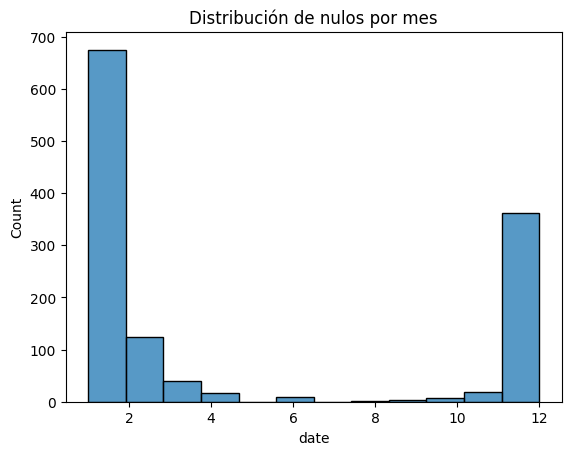

In [ ]:
#Seleccionamos las filas problemáticas de los no incendios y visualizamos
no_incendiosNulos = observar[observar.isna().any(axis=1)].index
j = pd.to_datetime(dfi['date'])
sns.histplot(j.iloc[no_incendiosNulos].dt.month, bins=12)
plt.title("Distribución de nulos por mes en los no incendios")

In [ ]:
#Estudiamos mes a mes los no incendios
for k in j.dt.month.unique():
    print(f"Mes {k}: {sum(j.dt.month == k)} filas")
    print(f"Mes {k} con nulos: {sum(j.iloc[no_incendiosNulos].dt.month == k)} filas")
    print(f"Porcentaje de nulos en el mes {k}: {sum(j.iloc[no_incendiosNulos].dt.month == k) / sum(j.dt.month == k) * 100:.2f}%\n")

Mes 7: 6227 filas
Mes 7 con nulos: 0 filas
Porcentaje de nulos en el mes 7: 0.00%

Mes 1: 6735 filas
Mes 1 con nulos: 675 filas
Porcentaje de nulos en el mes 1: 10.02%

Mes 8: 6127 filas
Mes 8 con nulos: 2 filas
Porcentaje de nulos en el mes 8: 0.03%

Mes 6: 6138 filas
Mes 6 con nulos: 10 filas
Porcentaje de nulos en el mes 6: 0.16%

Mes 9: 5863 filas
Mes 9 con nulos: 4 filas
Porcentaje de nulos en el mes 9: 0.07%

Mes 3: 6602 filas
Mes 3 con nulos: 40 filas
Porcentaje de nulos en el mes 3: 0.61%

Mes 2: 6585 filas
Mes 2 con nulos: 124 filas
Porcentaje de nulos en el mes 2: 1.88%

Mes 5: 6201 filas
Mes 5 con nulos: 0 filas
Porcentaje de nulos en el mes 5: 0.00%

Mes 4: 6374 filas
Mes 4 con nulos: 16 filas
Porcentaje de nulos en el mes 4: 0.25%

Mes 10: 5698 filas
Mes 10 con nulos: 7 filas
Porcentaje de nulos en el mes 10: 0.12%

Mes 11: 5555 filas
Mes 11 con nulos: 19 filas
Porcentaje de nulos en el mes 11: 0.34%

Mes 12: 5367 filas
Mes 12 con nulos: 361 filas
Porcentaje de nulos en el

##### Interpretación de los nulos en vegetación
Observando que la mayoría de nulos cae en época de invierno esto puede ser por la afluencia de las nubes. Decidimos entonces volver a realizar la extracción de la vegetación pero estableciendo un umbral de resolución para las nubes más bajo. Perderemos un poco de calidad en los datos pero recuperaremos valores nulos.

<Axes: xlabel='date', ylabel='Count'>

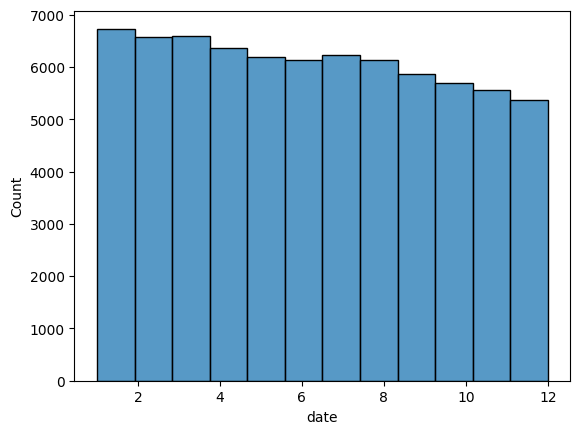

In [ ]:
sns.histplot(j.dt.month, bins=12)

##### Nulos de la vegetación en incendios en relación con las otras variables

In [ ]:
#El propio incendio
df_incendios.iloc[indices_observar_nulos]

,lat_mean,lon_mean,frp_sum,frp_mean,count,date_first,date_last,duration_days,area_ha,final
50574,45.143632,29.586695,3513.39,121.151379,29.0,2025-02-24 00:00:00,2025-02-25,2.0,3953.97,1
50595,45.220667,29.202433,1520.77,80.040526,19.0,2025-02-21 00:00:00,2025-03-22,30.0,5590.68,1
50675,46.484864,30.116416,984.27,140.610000,7.0,2025-02-23 00:00:00,2025-03-18,24.0,319.80,1
50903,45.541060,28.977045,166.48,83.240000,2.0,2025-02-21 00:00:00,2025-02-21,1.0,28.12,1


In [ ]:
#El Soil Organic Carbon
suelo.iloc[indices_observar_nulos]

,lat,lon,date,final,SOC
50574,45.143632,29.586695,2025-02-24,1,NaN
50595,45.220667,29.202433,2025-02-21,1,NaN
50675,46.484864,30.116416,2025-02-23,1,NaN
50903,45.541060,28.977045,2025-02-21,1,NaN


In [ ]:
#La pendiente
pendiente.iloc[indices_observar_nulos]

,lat,lon,date,final,elevacion_centro,grados,porcentaje
50574,45.143632,29.586695,2025-02-24,1,1.019634,0.193459,0.337650
50595,45.220667,29.202433,2025-02-21,1,2.782510,0.809968,1.413756
50675,46.484864,30.116416,2025-02-23,1,2.006430,0.271818,0.474416
50903,45.541060,28.977045,2025-02-21,1,20.542381,1.483990,2.590630


##### Decisiones tomadas
Al observar los indices que provocan nulos se observa que respecto a la vegetacion hay 6 puntos con datos nulos vinculados a incendios. Por otra parte hay 2083 vinculados a no incendios. Borraremos todos salvo un punto de incendio cuyo area y duracion destaca. Hay un dato atipico que fisicamente extraño ya que indica que 4000 ha se sofocan en 2 dias.

Cabe destacar el hecho de que todos los incendios nulos salvo 2 (incluido el conservado) tienen un SOC tambien nulo por lo que es positivo eliminarlos

### ANALISIS SOC + INCENDIOS

In [ ]:
#Seleccionamos las filas problemáticas de los incendios
analisis = suelo[suelo["final"] == 1]
print(analisis.isna().sum(), len(analisis), len(suelo))
print(f'Porcentaje de filas con nulos en "analisis": {analisis.isna().any(axis=1).mean() * 100:.2f}%')

lat         0
lon         0
date        0
final       0
SOC      1456
dtype: int64 2757 73472
Porcentaje de filas con nulos en "analisis": 52.81%


In [ ]:
#Seleccionamos las filas problemáticas de los no incendios
observar = suelo[suelo["final"] == 0]
print(observar.isna().sum(), len(observar), len(suelo))
print(f'Porcentaje de filas con nulos en "observar": {observar.isna().any(axis=1).mean() * 100:.2f}%')


lat          0
lon          0
date         0
final        0
SOC      17457
dtype: int64 70715 73472
Porcentaje de filas con nulos en "observar": 24.69%


In [ ]:
indices_observar_nulos = analisis[analisis.isna().any(axis=1)].index
print(f"Filas con nulos en 'observar': {indices_observar_nulos}")

Filas con nulos en 'observar': Index([    3,     7,     9,    15,    18,    21,    24,    25,    30,    31,
       ...
       51376, 51377, 51378, 51379, 51380, 51382, 51383, 51385, 51387, 51389],
      dtype='int64', length=1456)


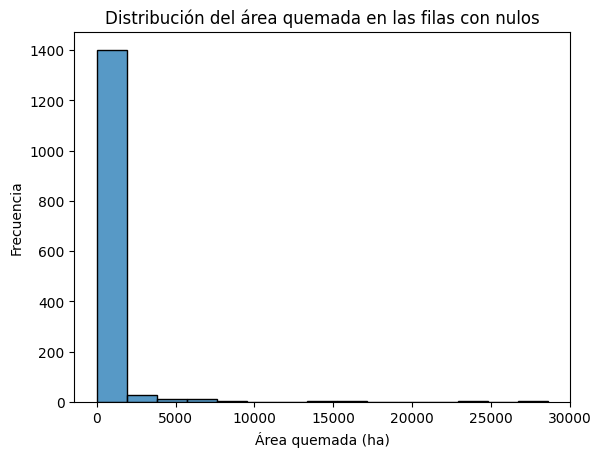

In [ ]:
borrar = df_incendios.iloc[indices_observar_nulos]
sns.histplot(borrar['area_ha'], bins=15)
plt.title("Distribución del área quemada en las filas con nulos")
plt.xlabel("Área quemada (ha)")
plt.ylabel("Frecuencia")
plt.show()

El suelo presenta un grave problema ya que mas del 50% de los datos que afectan a incendios son nulos, lo cual no se puede solucionar solo con el borrado

Ademas tambien esta variable el 25% de sus datos que afectan a no incendios tambien son nulo. 

Basicamente esta variable aunque sea informativa **no aporta los suficientes datos como para ser concluyente por lo que se ignora**

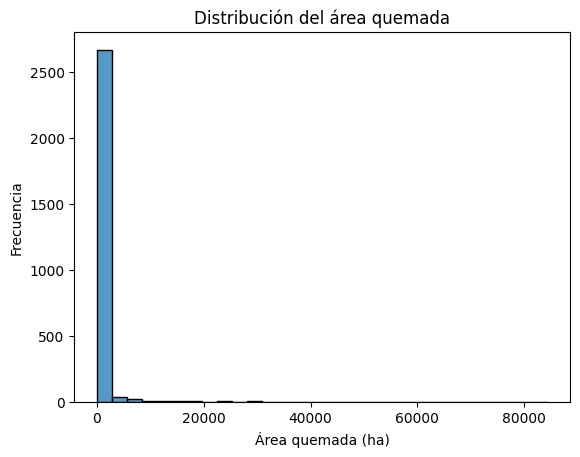

In [ ]:
sns.histplot(df_incendios['area_ha'], bins=30)
plt.title("Distribución del área quemada")
plt.xlabel("Área quemada (ha)")
plt.ylabel("Frecuencia")
plt.show()

### ANALISIS DE FISICAS + INCENDIOS

In [ ]:
#Seleccionamos las filas problemáticas de los incendios
analisis = fisicas[fisicas["final"] == 1]
print(analisis.isna().sum(), len(analisis), len(fisicas))
print('Porcentaje de filas con nulos en "analisis": {:.2f}%'.format(analisis.isna().any(axis=1).mean() * 100))

lat                    0
lon                    0
date                   0
final                  0
temp_mean             40
temp_max              40
temp_min              40
humidity_mean         40
precipitation         40
wind_speed_max        40
wind_gusts_max        40
pressure_mean         40
cloud_cover           40
radiation             40
evapotranspiration    40
sunshine_seconds      40
dtype: int64 2728 73443
Porcentaje de filas con nulos en "analisis": 1.47%


In [ ]:
#Seleccionamos las filas problemáticas de los no incendios
observar = fisicas[fisicas["final"] == 0]
print(observar.isna().sum(), len(observar), len(fisicas))
no_incendiosNulosFisicas = observar[observar.isna().any(axis=1)].index

lat                     0
lon                     0
date                    0
final                   0
temp_mean             726
temp_max              726
temp_min              726
humidity_mean         726
precipitation         726
wind_speed_max        726
wind_gusts_max        726
pressure_mean         726
cloud_cover           726
radiation             726
evapotranspiration    726
sunshine_seconds      726
dtype: int64 70715 73443


Text(0.5, 1.0, 'Distribución de Incendios por Mes')

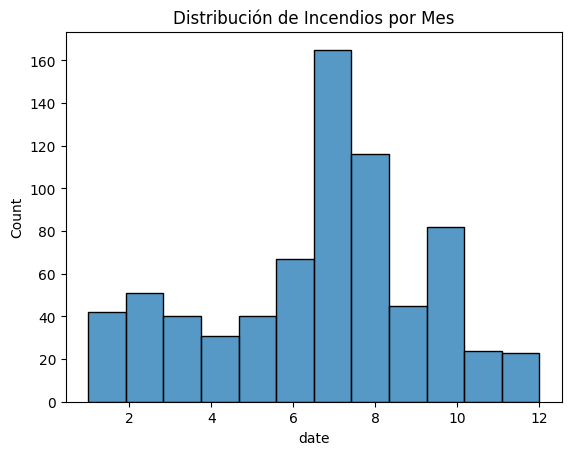

In [ ]:
sns.histplot(j.iloc[no_incendiosNulosFisicas].dt.month, bins=12)
plt.title("Distribución de Incendios por Mes")

In [ ]:
print(len(no_incendiosNulosFisicas), len(no_incendiosNulos))

726 1258


1983


Text(0.5, 1.0, 'Distribución de Incendios por Mes (Total Nulos)')

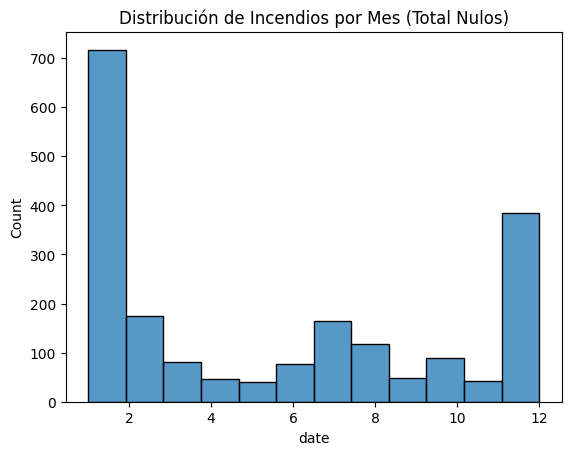

In [ ]:
indiceTotal = set(no_incendiosNulos).union(set(no_incendiosNulosFisicas))
print(len(indiceTotal))
sns.histplot(j.iloc[list(indiceTotal)].dt.month, bins=12)
plt.title("Distribución de Incendios por Mes (Total Nulos)")

In [ ]:
analisis = pendiente[pendiente["final"] == 1]
print(analisis.isna().sum(), len(analisis), len(pendiente))
print('Porcentaje de filas con nulos en "analisis": {:.2f}%'.format(analisis.isna().any(axis=1).mean() * 100))

lat                 0
lon                 0
date                0
final               0
elevacion_centro    0
grados              2
porcentaje          0
dtype: int64 2757 73472
Porcentaje de filas con nulos en "analisis": 0.07%


In [ ]:
observar = pendiente[pendiente["final"] == 0]
print(observar.isna().sum(), len(observar), len(pendiente))
print('Porcentaje de filas con nulos en "observar": {:.2f}%'.format(observar.isna().any(axis=1).mean() * 100))

lat                  0
lon                  0
date                 0
final                0
elevacion_centro    20
grados              79
porcentaje           0
dtype: int64 70715 73472
Porcentaje de filas con nulos en "observar": 0.11%


Text(0.5, 1.0, 'Distribución de Incendios por Mes (Pendiente con nulos)')

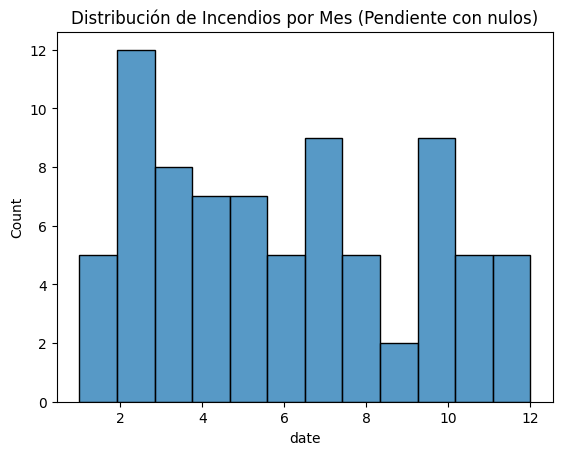

In [ ]:
pendiente_sinteticosNulos = observar[observar.isna().any(axis=1)].index
sns.histplot(j.iloc[pendiente_sinteticosNulos].dt.month, bins=12)
plt.title("Distribución de Incendios por Mes (Pendiente con nulos)")

### VEGETACIÓN2 (TIPO DE VEGETACIÓN) + INCENDIOS

In [ ]:
#Seleccionamos las filas problemáticas de los incendios
analisis = vegetacion2[vegetacion2["final"] == 1]
#Sabemos que para los datos sintéticos no hay valores desconocidos,
# puesto que se filtró a la hora de extraerlos.
# analisis2 = vegetacion[vegetacion2["final"] == 0]

total = len(analisis[analisis["vegetacion2"] == "Otro"])

print("Total de datos:", len(vegetacion2), '\n')
print("Total de incendios:", len(analisis), '\n')
print("Incendios con tipo de vegetación desconocida", total, '\n')

Total de datos: 73470 

Total de incendios: 2757 

Incendios con tipo de vegetación desconocida 989 



In [ ]:
# Transformar a UTM (Metros)
vegetacion2 = vegetacion2[(vegetacion2['lon'] >= -180)]
x_utm, y_utm, _, _ = utm.from_latlon(vegetacion2['lat'].values, vegetacion2['lon'].values)

# Asignamos las nuevas coordenadas a columnas nuevas
vegetacion2['x_utm'] = x_utm
vegetacion2['y_utm'] = y_utm

df_conocidos = vegetacion2[vegetacion2["vegetacion2"] != "Otro"].copy()
df_desconocidos = vegetacion2[vegetacion2["vegetacion2"] == "Otro"].copy()

X = df_conocidos[["x_utm", "y_utm"]]
y = df_conocidos["vegetacion2"]

# Validación
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

scores = []
k_range = range(1, 30) # Probamos de 1 a 30 vecinos

#Buscamos el mejor k
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance', metric='euclidean')
    knn.fit(X_train, y_train)
    score = knn.score(X_val, y_val)
    scores.append(score)

best_k = k_range[scores.index(max(scores))]
print(f"El mejor K es: {best_k} con una accuracy de {max(scores):.2f}")

El mejor K es: 28 con una accuracy de 0.59


# CONCLUSION

Nuestra conclusion es la siguiente:

Los nulos presentes en fisicas son borrables porque no afectan en mayor medida a los incendios ni tampoco a la distribucion de los puntos sinteticos. Los nulos solo afectan al 1% de los incendios y los sinteticos. **No es una variable problematica**.

Sin embargo, los nulos presentes en vegetacion presentan un sesgo importante: afectan en mayor medida (mas de 10 veces) a los meses de diciembre y enero debido a su nubosidad. Hemos corregido esto mediante un cambio en los parametros de entrada

La pendiente por su parte afecta a 133 incendios lo cual es importante ya que es el 5% de los datos que tenemos de esa clase. Ademas, hay 9000 nulos que afectan de manera equitativa mensualmente a los puntos sinteticos, representando mas del 10% de los datos sinteticos. Hay que revisar esta variable

En cuanto a vegetación2 (tipos de vegetación), también se ha llevado a cabo un análisis de nulos. La mayoría de datos desconocidos pertenecían a incendios.
Se intentó llevar a cabo un knn con accuracy del 59%, lo que tiene sentido, pues las muestras que tenemos no representan todas las clases de forma equitativa, ni tenemos datos de todas las muestras. Esto explica que el modelo no aprenda la distribución real, ni las características propias de cada tipo. 
También se ha llevado a cabo un proceso de obtención del tipo de vegetación en puntos cercanos para intentar sanear estos datos desconocidos, pero estos también lo eran, por lo que no ha sido posible.

### POSTERIOR
(ignorar por ahora)

A partir de las decisiones tomadas y con nuestro dataframe final, hacemos la limpieza

In [ ]:
df_final = mf.bajar_fichero(mf.crear_cliente(), path_server=f"grupo3/raw/Final/final_2022.parquet", type="df")

Dataframe importado correctamente


In [ ]:
#Volvemos a ver los nulos en Físicas
no_incendios = df_final.loc[df_final["date_last"].isna(), "precipitation"].isna().sum()
incendios = df_final["precipitation"].isna().sum() - no_incendios

print(5*"=", "IMPACTO NULOS", 5*"=")
print(f"No incendios nulos: {no_incendios}")
print(f"Incendios nulos: {incendios}")
print(f"La proporción de incendios y no incendios es de: {round(1/30, 2)} y la de nulos ha sido de: {round(incendios/no_incendios, 2)}")

no_incendios = df_final["date_last"].isna().sum() - no_incendios
incendios = len(df_final) - no_incendios - incendios

print(5*"=", "IMPACTO GLOBAL", 5*"=")
print(f"No incendios: {no_incendios}")
print(f"Incendios: {incendios}")
print(f"La proporción de incendios y no incendios eliminando las filas es de: {round(incendios/no_incendios, 2)}")

===== IMPACTO NULOS =====
No incendios nulos: 62
Incendios nulos: 21
La proporción de incendios y no incendios es de: 0.03 y la de nulos ha sido de: 0.34
===== IMPACTO GLOBAL =====
No incendios: 20493
Incendios: 845
La proporción de incendios y no incendios eliminando las filas es de: 0.04


In [ ]:
#Eliminamos las filas nulas de físicas
print(f"Dataframe antiguo: {len(df_final)}")
df_final.dropna(subset=["precipitation"], inplace = True)
print(print(f"Dataframe nuevo: {len(df_final)}"))

Dataframe antiguo: 21359
Dataframe nuevo: 21276
None


In [ ]:
cliente = mf.crear_cliente()

ruta_minio = bucket_name + '/' + file_name

df_incendios = mf.bajar_fichero(cliente, path_server=ruta_minio, type="df")

if df_incendios is None:
    print("Se ha producido un error al descargar el archivo.")

assert not df_incendios.empty, "El DataFrame descargado está vacío. Verifica el archivo en MinIO."

# Hasta aqui se ha descargado el archivo, ahora empieza la limipieza de datos

condicion_no_es_otro = df_incendios['vegetacion2'].astype(str).str.strip().str.lower() != 'otro'

condicion_no_es_sinDatos = df_incendios['vegetacion2'].astype(str).str.strip().str.lower() != 'sin datos'

df_incendios = df_incendios[condicion_no_es_sinDatos & condicion_no_es_otro]

# Quito las posibles zonas de agua y urbanas

aguaUrbano = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 34, 33, 36, 37, 38, 39, 40, 41, 42, 43]

df_mapa = mf.bajar_fichero(cliente, path_server="grupo3/mapa/mapa_vegetacion.csv", type="df")
ecosistemas_ignorar = df_mapa.loc[df_mapa['Unnamed: 0'].isin(aguaUrbano), 'Column6'].tolist()

df_incendios = df_incendios[
(~df_incendios['vegetacion2'].isin(ecosistemas_ignorar))]

#Limpieza de nulos

# mf.subir_fichero(cliente, ruta_minio, df_incendios)

NameError: name 'bucket_name' is not defined